In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
##carregando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np

#faz com que gráficos do Matplotlib apareçam diretamente dentro da célula de saída do notebook
%matplotlib inline


# **LABORATÓRIO — K-MEANS (CLUSTERIZAÇÃO)** #

## **Objetivo** ##

Agrupar clientes com base em características de consumo e identificar padrões de comportamento. Trata-se, portanto, de um problema de aprendizado não supervisionado, pois não há uma variável alvo previamente definida.

## **1. Business Understanding** ##

O objetivo deste experimento é segmentar clientes de um shopping center com base em características como renda anual e pontuação de gasto.

A segmentação de clientes permite identificar perfis distintos, auxiliando estratégias de marketing, personalização de ofertas e tomada de decisão gerencial.

## **2. Data Understanding** ##

O dataset foi obtido na url:
https://www.kaggle.com/datasets/shwetabh123/mall-customers

Arquivo: Mall_Customers.csv


O conjunto de dados contém informações sobre clientes de um shopping, incluindo:

- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

Para este experimento, serão utilizadas as variáveis:

- Annual Income
- Spending Score

Essas variáveis permitem identificar padrões de consumo e segmentar clientes com base em comportamento financeiro.

Forma do dataframe (linhas x colunas):
********************************************************************
Dados:
********************************************************************
Análise Exploratória:


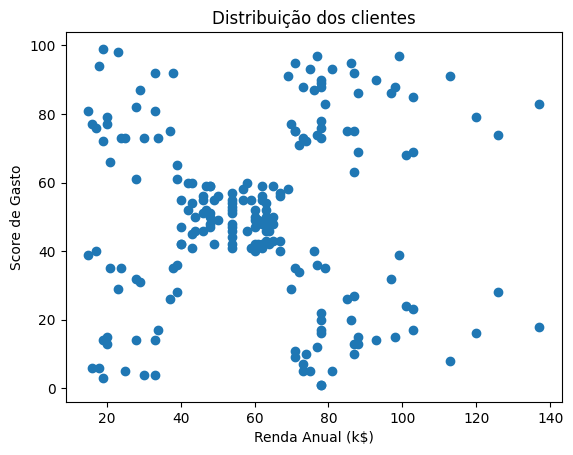

In [ ]:

# importando dados do dataset para um dataframe
id_csv = '1B8KQzFrEa3k0wM9PnollobpCSgpxMPVL'
url_csv = f'https://drive.google.com/uc?id={id_csv}'
df = pd.read_csv(url_csv)

print("Forma do dataframe (linhas x colunas):")
df.shape

print("********************************************************************")
print("Dados:")
df.head()


print("********************************************************************")
print("Análise Exploratória:")
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])
plt.xlabel("Renda Anual (k$)")
plt.ylabel("Score de Gasto")
plt.title("Distribuição dos clientes")
plt.show()

**Interpretação**

Já existe estrutura visível para:
- clientes com alta renda e alto gasto
- clientes com alta renda e baixo gasto
- clientes com baixa renda e alto gasto

---
## **3. Data Preparation** ##

Tem-se que padronizar os dados de entrada e escolher o número de clusters.

Para escolher o número de clusters vamos utilizar o método do "cotovelo" (o ponto onde o ganho começa a diminuir).

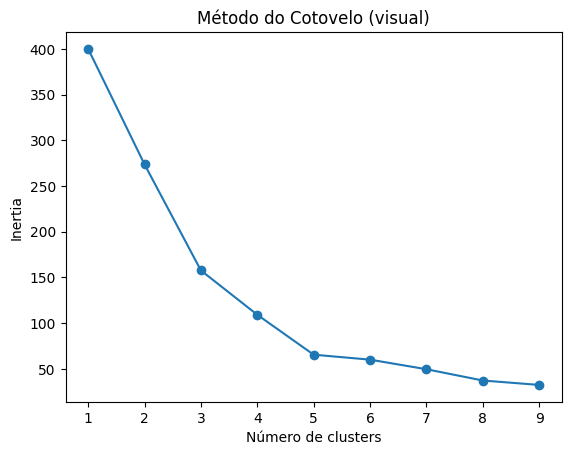

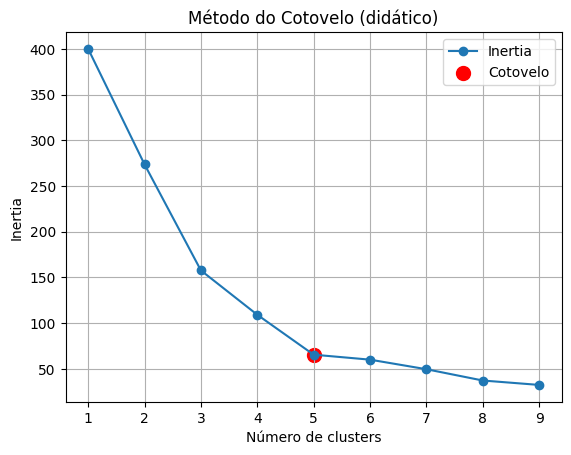

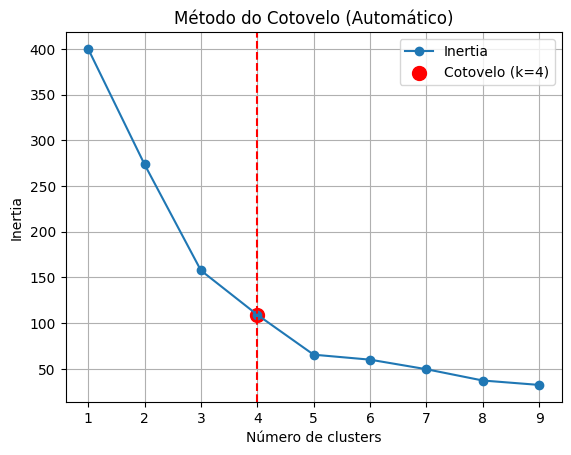

In [ ]:


# aplicando padronização

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Escolhendo o número de clusters pelo método do cotovelo (elbow)

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo (visual)")
plt.show()

#método do cotovelo didático

inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Suponha que o cotovelo visual foi em k = 5
k_cotovelo = 5

plt.plot(K, inertia, marker='o', label="Inertia")

# Destacar o cotovelo
plt.scatter(k_cotovelo, inertia[k_cotovelo - 1],
            color='red', s=100, label="Cotovelo")

plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo (didático)")
plt.legend()
plt.grid(True)
plt.show()

#---------------------------------------------
# Tentando automatizar o método do cotovelo
#---------------------------------------------

# método do cotovelo "automático"
!pip install kneed -q

from kneed import KneeLocator

kneedle = KneeLocator(K, inertia, curve='convex', direction='decreasing')

k_cotovelo = kneedle.knee

plt.plot(K, inertia, marker='o', label="Inertia")

# Destacar o cotovelo automaticamente
plt.scatter(k_cotovelo, inertia[k_cotovelo - 1],
            color='red', s=100, label=f"Cotovelo (k={k_cotovelo})")
 # insere a linha vermelha
plt.axvline(x=k_cotovelo, color='red', linestyle='--')
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo (Automático)")
plt.legend()
plt.grid(True)
plt.show()


### **🧠 Interpretação** ###

**Intuição visual**

A curva faz isso:
- queda forte ↓↓↓
- quebra de inclinação ← aqui está o cotovelo
- queda suave →

Essa “quebra” ocorre em k ≈ 4

Se formos estritamente pela visualização da curva, o achatamento mais claro começa de 5 para 6. Então:

k = 5 é um candidato muito forte ao cotovelo
k = 4 pode ser visto como a região de transição
k = 5 é o ponto onde o ganho adicional começa a ficar bem menor

Para entender melhor vamos observar a queda da inércia:

| k     | Queda da Inércia    |
| ----- | ------------------- |
| 1 → 2 | grande              |
| 2 → 3 | grande              |
| 3 → 4 | ainda significativa |  
| 4 → 5 | região de transição |
| 5 → 6 | começa a achatar    |
| 6 → 9 | queda pequena       |


**Por que o método automático apontou k = 4?**

O método automático (tipo Kneedle) não “olha” o gráfico como um humano. Ele usa critério matemático de curvatura.
Porque matematicamente o ponto de maior “quebra” (curvatura máxima) ocorre em k = 4, não em 5.

**👁️ Olho humano (visual)**

 Nós vemos: “a curva começa a achatar depois do 5”
- correto visualmente ✔
- interpretação baseada na inclinação percebida ✔

**🤖 Método automático**

 O algoritmo percebe: “onde a curva muda mais abruptamente de direção?”

O que acontece no gráfico:
- 1 → 2 → 3 → 4 → queda forte
- 3 → 4 → quebra mais brusca de inclinação
- 4 → 5 ainda cai bem
- 5 → 6 começa o achatamento

Nesse caso, a mudança mais brusca de inclinação acontece em 4.

**Resumindo a divergência**

| Interpretação        | Resultado |
| -------------------- | --------- |
| Visual humana        | k = 5     |
| Curvatura matemática | k = 4     |

**Qual usar?**

Ambos estão corretos, dependendo do objetivo:

Use k = 4 quando:
- quer modelo mais simples
- quer evitar overfitting
- quer menos clusters

Use k = 5 quando:
- quer mais granularidade
- clusters fazem sentido no negócio
- diferença ainda agrega valor

**⚠️ Insight importante**

- O método do cotovelo não é exato — é heurístico.
- Às vezes não existe cotovelo claro ou existem vários.
- O cotovelo não é um ponto exato, é uma região. Nesse caso em específico: região do cotovelo = [4, 5]

---
### **Outras Técnicas** ##

Vamos conhecer outras técnicas para escolher o número de clusters (k) ideal. Sendo:

**1. Pontuação de Silhueta (*Silhouette Score*)**

Mede cada ponto:
- a = distância média para pontos do mesmo cluster
- b = distância média para o cluster mais próximo

**Fórmula:**
$$ Silhouette = \frac{b-a} {max(a,b)} $$


**Interpretação**
| Valor | Qualidade              |
| ----- | ---------------------- |
| ≈ 1   | clusters bem separados |
| ≈ 0.5 | razoável               |
| ≈ 0   | clusters sobrepostos   |
| < 0   | clusters ruins         |



In [ ]:
k_values = range(2, 10)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

for k, score in zip(k_values, silhouette_scores):
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.396
k=3, silhouette=0.468
k=4, silhouette=0.494
k=5, silhouette=0.554
k=6, silhouette=0.513
k=7, silhouette=0.502
k=8, silhouette=0.496
k=9, silhouette=0.456


Como escolher k com a pontuação de silhueta?

👉 escolha o **k** com **maior silhouette score**! Nesse caso: K=5.


**2. Davies-Bouldin Index**

Avalia:
- compactação interna dos clusters
- separação entre clusters

**Como interpretar?**

| Valor       | Qualidade |
| ----------- | --------- |
| baixo (→ 0) | melhor    |
| alto        | pior      |



In [ ]:
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    db_scores.append(score)

for k, score in zip(k_values, db_scores):
    print(f"k={k}, DB={score:.3f}")

k=2, DB=1.070
k=3, DB=0.715
k=4, DB=0.697
k=5, DB=0.573
k=6, DB=0.625
k=7, DB=0.691
k=8, DB=0.742
k=9, DB=0.806


Como escolher k com o índice de Davies_Bouldin?

👉 escolha o **k** com menor **valor**!  Nesse caso: K=5.



## Estratégia profissional ##

Não use apenas um. Combine os resultados para validação e para uma melhor decisão.

| Método         | Critério           |
| -------------- | ------------------ |
| Cotovelo       | redução de inércia |
| Silhouette     | maximizar          |
| Davies-Bouldin | minimizar          |


**Exemplo**

| k | Inércia     | Silhouette ↑ | DB  ↓    |
| - | ----------- | ------------ | -------- |
| 4 | bom         | 0.49         | 0.69     |
| 5 | melhor      | **0.55**     | **0.57** |
| 6 | pouco ganho | 0.51         | 0.62     |


### Escolha do K Ideal Usando as Três Métricas ###


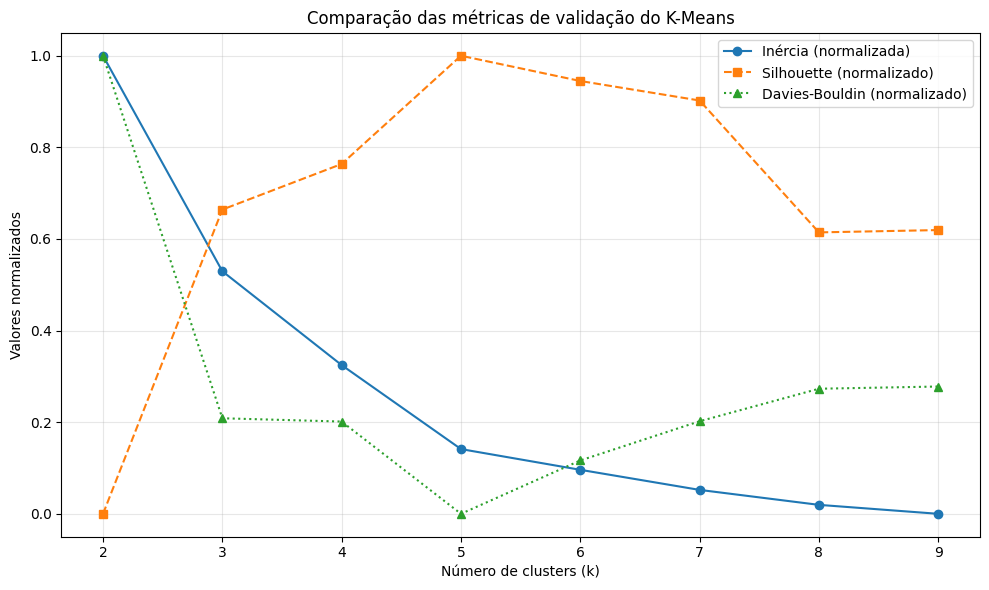

In [ ]:

k_values = range(2, 10)

inertias = []
silhouette_scores = []
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

# Normalização para mesma escala visual
scaler = MinMaxScaler()
metrics = np.array([inertias, silhouette_scores, db_scores]).T
metrics_norm = scaler.fit_transform(metrics)

inertias_norm = metrics_norm[:, 0]
silhouette_norm = metrics_norm[:, 1]
db_norm = metrics_norm[:, 2]

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias_norm, marker='o', label='Inércia (normalizada)')
plt.plot(k_values, silhouette_norm, marker='s', linestyle='--', label='Silhouette (normalizado)')
plt.plot(k_values, db_norm, marker='^', linestyle=':', label='Davies-Bouldin (normalizado)')

plt.xlabel('Número de clusters (k)')
plt.ylabel('Valores normalizados')
plt.title('Comparação das métricas de validação do K-Means')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

** Lembrando como como interpretar: **
- **Inércia:** quanto menor, melhor, mas você busca o ponto de “quebra”.
- **Silhouette Score:** quanto maior, melhor.
- **Davies-Bouldin Index:** quanto menor, melhor.

---

## **4. Modelagem (K-means)** ##





In [ ]:
# Pipeline com padronização + K-means
pipeline_kmeans = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=5, random_state=42))
])

# Ajustar o pipeline aos dados
pipeline_kmeans.fit(X)

# Obter os rótulos dos clusters gerados pelo K-means
df["Cluster"] = pipeline_kmeans.named_steps["kmeans"].labels_


## **5. Visualização e Interpretação dos Clusters** ##

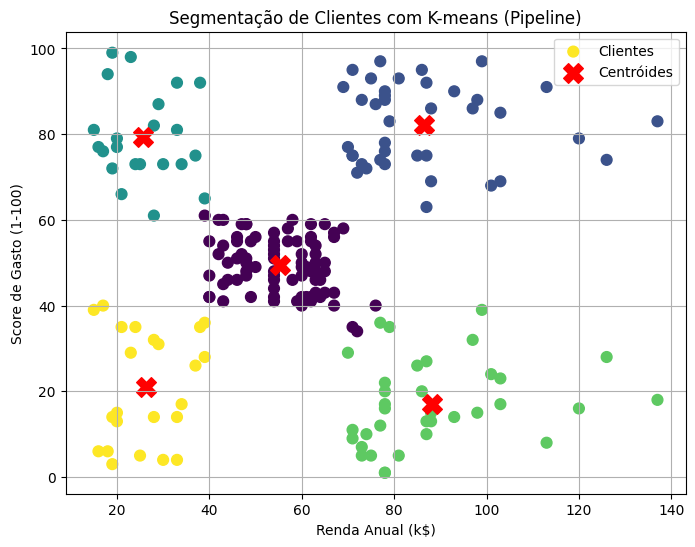

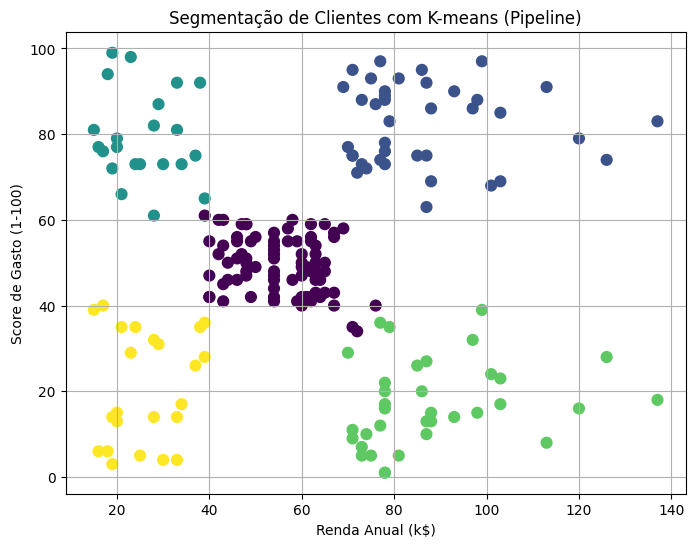

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [ ]:

# Recuperar centróides na escala padronizada
centroides_padronizados = pipeline_kmeans.named_steps["kmeans"].cluster_centers_

# Trazer os centróides de volta para a escala original
centroides_originais = pipeline_kmeans.named_steps["scaler"].inverse_transform(centroides_padronizados)

# Plot com clusters + centróides
plt.figure(figsize=(8, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60,
    label="Clientes"
)

plt.scatter(
    centroides_originais[:, 0],
    centroides_originais[:, 1],
    c="red",
    s=200,
    marker="X",
    label="Centróides"
)

plt.xlabel("Renda Anual (k$)")
plt.ylabel("Score de Gasto (1-100)")
plt.title("Segmentação de Clientes com K-means (Pipeline)")
plt.legend()
plt.grid(True)
plt.show()


# Visualização dos clusters sem os centróides
plt.figure(figsize=(8, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel("Renda Anual (k$)")
plt.ylabel("Score de Gasto (1-100)")
plt.title("Segmentação de Clientes com K-means (Pipeline)")
plt.grid(True)
plt.show()

df.groupby("Cluster").mean(numeric_only=True)

### **🧠 Interpretação dos Clusters** ###

**Perfis segmentados:**

- Cluster 0 → alta renda, alto gasto → clientes premium
- Cluster 1 → alta renda, baixo gasto → potencial de marketing
- Cluster 2 → baixa renda, alto gasto → clientes impulsivos
- Cluster 3 → baixa renda, baixo gasto → baixo valor
- Cluster 4 → intermediários

## **6. Deployment (discussão)** ##

Os clusters identificados podem ser utilizados para:

- campanhas segmentadas
- definição de ofertas personalizadas
- estratégias de retenção de clientes
- análise de comportamento de consumo

A segmentação permite transformar dados em ações estratégicas.


## **💡 Insight** ##

> “Sem variável alvo, o modelo não prevê ou classifica - ele revela estrutura escondida nos dados.”

---

# **Proposta para Campanha de Marketing** #

Assumindo os perfis típicos:

| Cluster | Perfil    | Característica              |
| ------- | --------- | --------------------------- |
| C0      | Premium   | Alta renda + alto gasto     |
| C1      | Econômico | Baixa renda + baixo gasto   |
| C2      | Potencial | Alta renda + baixo gasto    |
| C3      | Impulsivo | Baixa renda + alto gasto    |
| C4      | Médio     | Comportamento intermediário |


## Estratégia por Perfil ##


### 💎 1️⃣Cluster Premium (Alta renda / alto gasto) ###

**🎯 Objetivo**

Fidelização e aumento de ticket médio

**📢 Ações**

- programa VIP
- acesso antecipado a produtos
- eventos exclusivos
- descontos personalizados

**💬 Mensagem**

> “Experiência exclusiva para clientes especiais”

### 💡 2️⃣ Cluster Potencial (Alta renda / baixo gasto) ###

👉 Esse é o cluster mais importante.

**🎯 Objetivo**

Converter em alto gasto

**📢 Ações**

- campanhas personalizadas
- recomendações inteligentes
- cupons direcionados
- remarketing

**💬 Mensagem**

> “Descubra produtos feitos para você”


### 🔥 3️⃣ Cluster Impulsivo (Baixa renda / alto gasto) ###

**🎯 Objetivo**

Manter engajamento sem gerar churn financeiro

**📢 Ações**

- promoções frequentes
- combos
- cashback
- gamificação

**💬 Mensagem**

> “Ofertas imperdíveis por tempo limitado”


### 🧊 4️⃣ Cluster Econômico (Baixa renda / baixo gasto) ###

**🎯 Objetivo**

Ativar consumo

**📢 Ações**

- descontos agressivos
- frete grátis
- produtos de entrada
- campanhas de volume

**💬 Mensagem**
> “Qualidade com o melhor preço”

### ⚖️ 5️⃣ Cluster Intermediário ###

**🎯 Objetivo**

Empurrar para clusters mais lucrativos

**📢 Ações**
- **Cross-sell:** Oferecer produtos complementares ao que o cliente já comprou ou está comprando.
- **Upsell:** Oferecer uma versão melhor, mais cara ou mais completa do produto que ele iria levar.
- sugestões baseadas em comportamento
